Full data analysis and visualization script -- you'll be able to reproduce near-identical figure as in the paper just by starting a full run!

In [1]:
import re
import os
import json
import copy
import math
import random
import numpy as np
import pandas as pd
random.seed(3407)

from tqdm import tqdm
from datetime import datetime, timedelta
from lexicalrichness import LexicalRichness
import scipy.stats as stats
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
## We have saved all encoded data -- no need to call a text-encoding model on-the-fly!

# import torch
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(torch.cuda.get_device_name(0))

# from sentence_transformers import SentenceTransformer
# model = SentenceTransformer('Alibaba-NLP/gte-large-en-v1.5', trust_remote_code=True, device=device)

In [3]:
# Load local file saved for long term users (including gte embeddings)
_ds = dict(np.load('datasets/wildchat/core_user_encoded.npz', allow_pickle=True))
ds = {k:v for k,v in _ds.items() if len(v)>1}
print(len(ds))
print(sum([len(ds[d]) for d in ds]))

2092
59175


Note: Many later experiments have dependencies on earlier ones (mainly the data construction for Figure 2). It is recommended to complete a full run of the notebook in its current order.

#### Figure 2: Overview of the ReCCRE dataset as a user-level 2-D plot with anchor points

In [4]:
# "Anchor points" as base categtories in the visualization
# Total of 41 anchor points over 11 categories

_selection = [
    # [R] only
    '__[REQUEST]__',
    '__[REQUEST]__!',
    "__[REQUEST]__:",
    
    # [R]*n
    "__[REQUEST]__ and __[REQUEST]__.",
    "__[REQUEST]__, so that __[REQUEST]__.",
    "__[REQUEST]__ but __[REQUEST]__.",
    "__[REQUEST]__. __[REQUEST]__. __[REQUEST]__.",
    
    # [R]-[C]
    "__[REQUEST]__ __[CONTEXT]__.",
    "__[REQUEST]__: __[CONTEXT]__",
    "__[REQUEST]__, where __[CONTEXT]__.",
    "__[REQUEST]__ such as __[CONTEXT]__.",
    
    # [C]-[R]
    "__[CONTEXT]__, __[REQUEST]__.",
    "__[CONTEXT]__. Now, __[REQUEST]__.",
    "__[CONTEXT]__. Next, __[REQUEST]__.",
    
    # [R]-[C]-[R]*n
    "__[REQUEST]__. __[CONTEXT]__. __[REQUEST]__.",
    "__[REQUEST]__ __[CONTEXT]__. __[REQUEST]__ and __[REQUEST]__.",
    "__[REQUEST]__ __[CONTEXT]__ __[REQUEST]__ __[REQUEST]__ __[REQUEST]__.",
    
    # [R]-[C]-[C]*n
    "__[REQUEST]__ based off __[CONTEXT]__: __[CONTEXT]__.",
    "__[REQUEST]__. __[CONTEXT]__. __[CONTEXT]__.",
    "__[REQUEST]__ __[CONTEXT]__ __[CONTEXT]__ __[CONTEXT]__.",
    
    # other R/C/r comp
    "__[REQUEST]__. __[REQUEST]__. __[REQUEST]__. __[CONTEXT]__. __[CONTEXT]__.",
    "__[REQUEST]__, __[CONTEXT]__. Then, __[REQUEST]__, __[CONTEXT]__. Finally, __[REQUEST]__, __[CONTEXT]__.",
    "__[CONTEXT]__, based on __[CONTEXT]__, __[REQUEST]__",
    
    # conversational - single R
    "please __[REQUEST]__",
    "Could you please __[REQUEST]__?",
    "How to __[REQUEST]__?",
    "Can you help me to __[REQUEST]__?",
    "Hi I wanna __[REQUEST]__.",
    "I need __[REQUEST]__.",
    
    # conversational - R + C/r
    "You are __[ROLE]__. __[REQUEST]__.",
    "I have __[CONTEXT]__, so __[REQUEST]__?",
    "Let's say __[CONTEXT]__. Now, __[REQUEST]__.",
    "Hi, you are __[ROLE]__ and now I want you to __[REQUEST]__.",
    "I'm working on __[CONTEXT]__ and I'd like you to __[REQUEST]__.",
    "Help me __[REQUEST]__: __[CONTEXT]__.",
    'Please __[REQUEST]__, based on __[CONTEXT]__.',
    
    # conversational - complex
    "How can I __[REQUEST]__? I'll also __[REQUEST]__ and __[REQUEST]__.",
    "__[REQUEST]__, and __[REQUEST]__. You will need to __[REQUEST]__.",
    "Act as __[ROLE]__ and __[REQUEST]__: __[CONTEXT]__ __[CONTEXT]__.",
    
    # referential/hypothetical & [C] only
    '__[CONTEXT]__',
    '__[CONTEXT]__ __[CONTEXT]__',
]

_grouping_selected = [
    # [R] only
    0,
    0,
    0,
    
    # [R]*n
    1,
    1,
    1,
    1,
    
    # [R]-[C]
    2,
    2,
    2,
    2,
    
    # [C]-[R]
    3,
    3,
    3,
    
    # [R]-[C]-[R]*n
    4,
    4,
    4,
    
    # [R]-[C]-[C]*n
    5,
    5,
    5,
    
    # other R/C/r comp
    6,
    6,
    6,
    
    # conversational - single R
    7,
    7,
    7,
    7,
    7,
    7,
    
    # conversational - R + C/r
    8,
    8,
    8,
    8,
    8,
    8,
    8,
    
    # conversational - complex
    9,
    9,
    9,
    
    # referential/hypothetical & [C] only
    10,
    10,
]

In [5]:
# Load complementary expression templates for more robust fit_transform

with open('datasets/complementary_baselines.json', 'r') as f1:
    comp_base_source = json.load(f1)
comp_baselines = []
for d in comp_base_source:
    for t in comp_base_source[d]:
        for item in comp_base_source[d][t]:
            comp_baselines.append(item)
print(comp_baselines)
print(len(comp_baselines))

['__[REQUEST]__.', '__[REQUEST]__!', '__[REQUEST]__?', '__[REQUEST]__:', 'Give __[REQUEST]__.', 'give __[REQUEST]__.', '__[REQUEST]__', 'Give __[REQUEST]__', 'give __[REQUEST]__', '__[REQUEST]__ __[REQUEST]__.', '__[REQUEST]__. __[REQUEST]__.', '__[REQUEST]__, __[REQUEST]__.', '__[REQUEST]__. __[REQUEST]__!', '__[REQUEST]__, and __[REQUEST]__.', '__[REQUEST]__ and __[REQUEST]__.', '__[REQUEST]__ but __[REQUEST]__.', '__[REQUEST]__, but __[REQUEST]__.', '__[REQUEST]__, so that __[REQUEST]__.', '__[REQUEST]__ __[REQUEST]__ __[REQUEST]__.', '__[REQUEST]__. __[REQUEST]__. __[REQUEST]__.', '__[REQUEST]__ __[REQUEST]__ __[REQUEST]__ __[REQUEST]__.', '__[REQUEST]__. __[REQUEST]__. __[REQUEST]__. __[REQUEST]__.', '__[REQUEST]__ __[REQUEST]__ __[REQUEST]__ __[REQUEST]__ __[REQUEST]__.', '__[REQUEST]__. __[REQUEST]__. __[REQUEST]__. __[REQUEST]__. __[REQUEST]__.', '__[REQUEST]__ __[REQUEST]__ __[REQUEST]__ and __[REQUEST]__.', '__[REQUEST]__ __[REQUEST]__ and __[REQUEST]__.', '__[REQUEST]__. __[

In [6]:
baselines = _selection + [item for item in comp_baselines if item not in _selection]
baselines = [s.strip() for s in baselines]
print(len(baselines))
_short_baselines = [s.replace('__[REQUEST]__', '[R]').replace('__[CONTEXT]__', '[C]').replace('__[ROLE]__', '[role]') for s in _selection] # Acronym for annotations & legends

e_bases = np.load('datasets/baseline_anchors_full.npy') # Encoded anchor points
print(len(e_bases))

287
287


In [7]:
# Utils for dimension reduction & visualization

def calc_rotate_angle(r_coord, c_coord):
    angle_rad = math.atan2(r_coord[1] - c_coord[1], r_coord[0] - c_coord[0])
    angle_deg = math.degrees(angle_rad)
    if angle_deg > 90 and angle_deg <= 180:
        angle_deg = 180.0 - angle_deg
    return angle_deg

def rotate(coords, angle):
    theta = np.deg2rad(angle)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]])
    rotated = coords @ R.T
    return rotated

In [8]:
user_reps_col = {}
user_reps_avg = {}
user_chat_count = {}
for user in tqdm(list(ds.keys())):
    req_embeds = [item['processed_first_turn']['encoded_formatting'] for item in ds[user] if item['processed_first_turn']['query_type'] == 'performing tasks']
    if len(req_embeds) >= 2:
        user_reps_col[user] = req_embeds
        user_reps_avg[user] = np.mean(req_embeds, axis=0)
        user_chat_count[user] = len(req_embeds)

100%|██████████| 2092/2092 [00:00<00:00, 9340.86it/s]


In [9]:
# Averaged embeddings for all users
user_avg_concat = np.concatenate(list(user_reps_avg.values()), axis=0)
print(user_avg_concat.shape)
_user_num = user_avg_concat.shape[0]
print(_user_num)

# Concatenate with the anchor points for dim-reduction
user_avg_concat = np.concatenate((user_avg_concat, e_bases), axis=0)
print(user_avg_concat.shape)

(2092, 1024)
2092
(2379, 1024)


In [ ]:
# Perform the dimension reduction

import pacmap
_seed = random.randint(0, 10000)
print(_seed) # 931
space = pacmap.PaCMAP(n_components=2, n_neighbors=20, random_state=_seed) # n_neighbors=None will let it automatically choose
reduced_embeds = space.fit_transform(user_avg_concat)
print(reduced_embeds.shape)

931
(2379, 2)


In [11]:
r_e_users = reduced_embeds[:_user_num] # All 2092 users
r_e_selected_bases = reduced_embeds[_user_num:_user_num+len(_selection)] # 41 anchor points to be displayed
r_e_comp_bases = reduced_embeds[_user_num+len(_selection):] # Other complementary anchor points
print(r_e_users.shape, r_e_selected_bases.shape, r_e_comp_bases.shape)
print(len(_short_baselines))

(2092, 2) (41, 2) (246, 2)
41


In [12]:
# Rotate such that [R] and [C] are parallel to the X-axis
_angle = calc_rotate_angle(r_e_selected_bases[0], r_e_selected_bases[-2])
reduced_embeds_alt = rotate(reduced_embeds, _angle)
r_e_users = reduced_embeds_alt[:_user_num]
r_e_selected_bases = reduced_embeds_alt[_user_num:_user_num+len(_selection)]
r_e_comp_bases = reduced_embeds_alt[_user_num+len(_selection):]
print(r_e_users.shape, r_e_selected_bases.shape, r_e_comp_bases.shape)

(2092, 2) (41, 2) (246, 2)


In [13]:
# Determine the closest group for *each session*

def cluster_by_anchors(input_coords=r_e_users, anchor_coords=r_e_selected_bases, anchor2group=_grouping_selected, threshold=4):
    distances = euclidean_distances(input_coords, r_e_selected_bases)
    min_dist = distances.min(axis=1)
    closest_anchor = distances.argmin(axis=1)
    assigned = np.where(min_dist <= threshold, closest_anchor, -1)
    color_groups = np.array([anchor2group[i] if i != -1 else max(anchor2group)+1 for i in assigned])

    _group_col = {i:0 for i in range(max(anchor2group)+2)}
    unique_values, counts = np.unique(assigned, return_counts=True)
    count_sort_ind = np.argsort(-counts)
    
    for idx in count_sort_ind:
        v, c = unique_values[idx], int(counts[idx])
        g = anchor2group[v]
        if v == -1:
            _group_col[max(anchor2group)+1] += c
        else:
            _group_col[g] += c
    
    return color_groups, _group_col

In [14]:
ds_by_anchor_cluster = {}
for user in tqdm(ds):
    _embeds = np.array([item['processed_first_turn']['encoded_formatting'].squeeze() for item in ds[user]])
    _reduced_embeds = space.transform(_embeds, basis=user_avg_concat)
    _reduced_embeds = rotate(_reduced_embeds, _angle)
    _g, _ = cluster_by_anchors(input_coords=_reduced_embeds)
    ds_by_anchor_cluster[user] = _g

100%|██████████| 2092/2092 [03:54<00:00,  8.90it/s]


In [15]:
# Find the conversational sessions of each user -- will be used in experiments for Figure 3

_ds_f = {}
for user in list(ds.keys()):
    _col = []
    for item, c in zip(ds[user], ds_by_anchor_cluster[user]):
        if c in [7, 8, 9]: # conversational
            _col.append(item)
    if len(_col):
        _ds_f[user] = _col

In [16]:
# Calculate user-level minimal distances to the anchors, and determine color group of users for visualization

distances = euclidean_distances(r_e_users, r_e_selected_bases)
min_dist = distances.min(axis=1)
closest_anchor = distances.argmin(axis=1)

threshold = 4 # Distance threshold for rejection ("None" type)
assigned = np.where(min_dist <= threshold, closest_anchor, -1)
color_groups = np.array([_grouping_selected[i] if i != -1 else max(_grouping_selected)+1 for i in assigned])

In [17]:
_12_colors = [
    "#12396c",  # 1 - dark navy blue 
    "#ff7f0e",  # 2 - orange
    "#34b934",  # 3 - green
    "#c31111",  # 4 - red
    "#8c5ebb",  # 5 - purple
    "#8c564b",  # 6 - brown
    "#e377c2",  # 7 - pink
    "#64ebfa",  # 8 - light cyan 
    "#16a3bf",  # 9 - mid-tone teal 
    "#0D5D6A",  # 10 - deep teal 
    "#dfcc1b",  # 11 - yellow-green 
    "#787878"   # 12 - grey for null
]

_legends = [
    '[R]',
    '[R]*n',
    '[R][C]',
    '[C][R]',
    '[R][C][R]+',
    '[R][C][C]+',
    'other R/C/r comp',
    'conversational - [R]',
    'conversational - [R]&[C/r]',
    'conversational - complex',
    'other/referential',
    'None'
]

_legends = {i:_legends[i] for i in range(len(_legends))}

1 100
[<matplotlib.lines.Line2D object at 0x74e9a8cc4710>, <matplotlib.lines.Line2D object at 0x74e9a8d0a950>, <matplotlib.lines.Line2D object at 0x74e9a8d0b210>, <matplotlib.lines.Line2D object at 0x74e9a8d0bb50>, <matplotlib.lines.Line2D object at 0x74e9a8ab84d0>, <matplotlib.lines.Line2D object at 0x74e9a8cff890>, <matplotlib.lines.Line2D object at 0x74e9a8cf1d10>, <matplotlib.lines.Line2D object at 0x74e9a8ab8e10>, <matplotlib.lines.Line2D object at 0x74e9a8ab96d0>, <matplotlib.lines.Line2D object at 0x74e9a8ab9e90>, <matplotlib.lines.Line2D object at 0x74e9a8aba850>, <matplotlib.lines.Line2D object at 0x74e9a8abb150>, <matplotlib.lines.Line2D object at 0x74e9a8abba90>, <matplotlib.lines.Line2D object at 0x74e9a8ac83d0>, <matplotlib.lines.Line2D object at 0x74e9a8ac8c90>, <matplotlib.lines.Line2D object at 0x74e9a8ac9390>, <matplotlib.lines.Line2D object at 0x74e9a8ac9c90>, <matplotlib.lines.Line2D object at 0x74e9a8aca550>, <matplotlib.lines.Line2D object at 0x74e9a8acae10>] ['gro

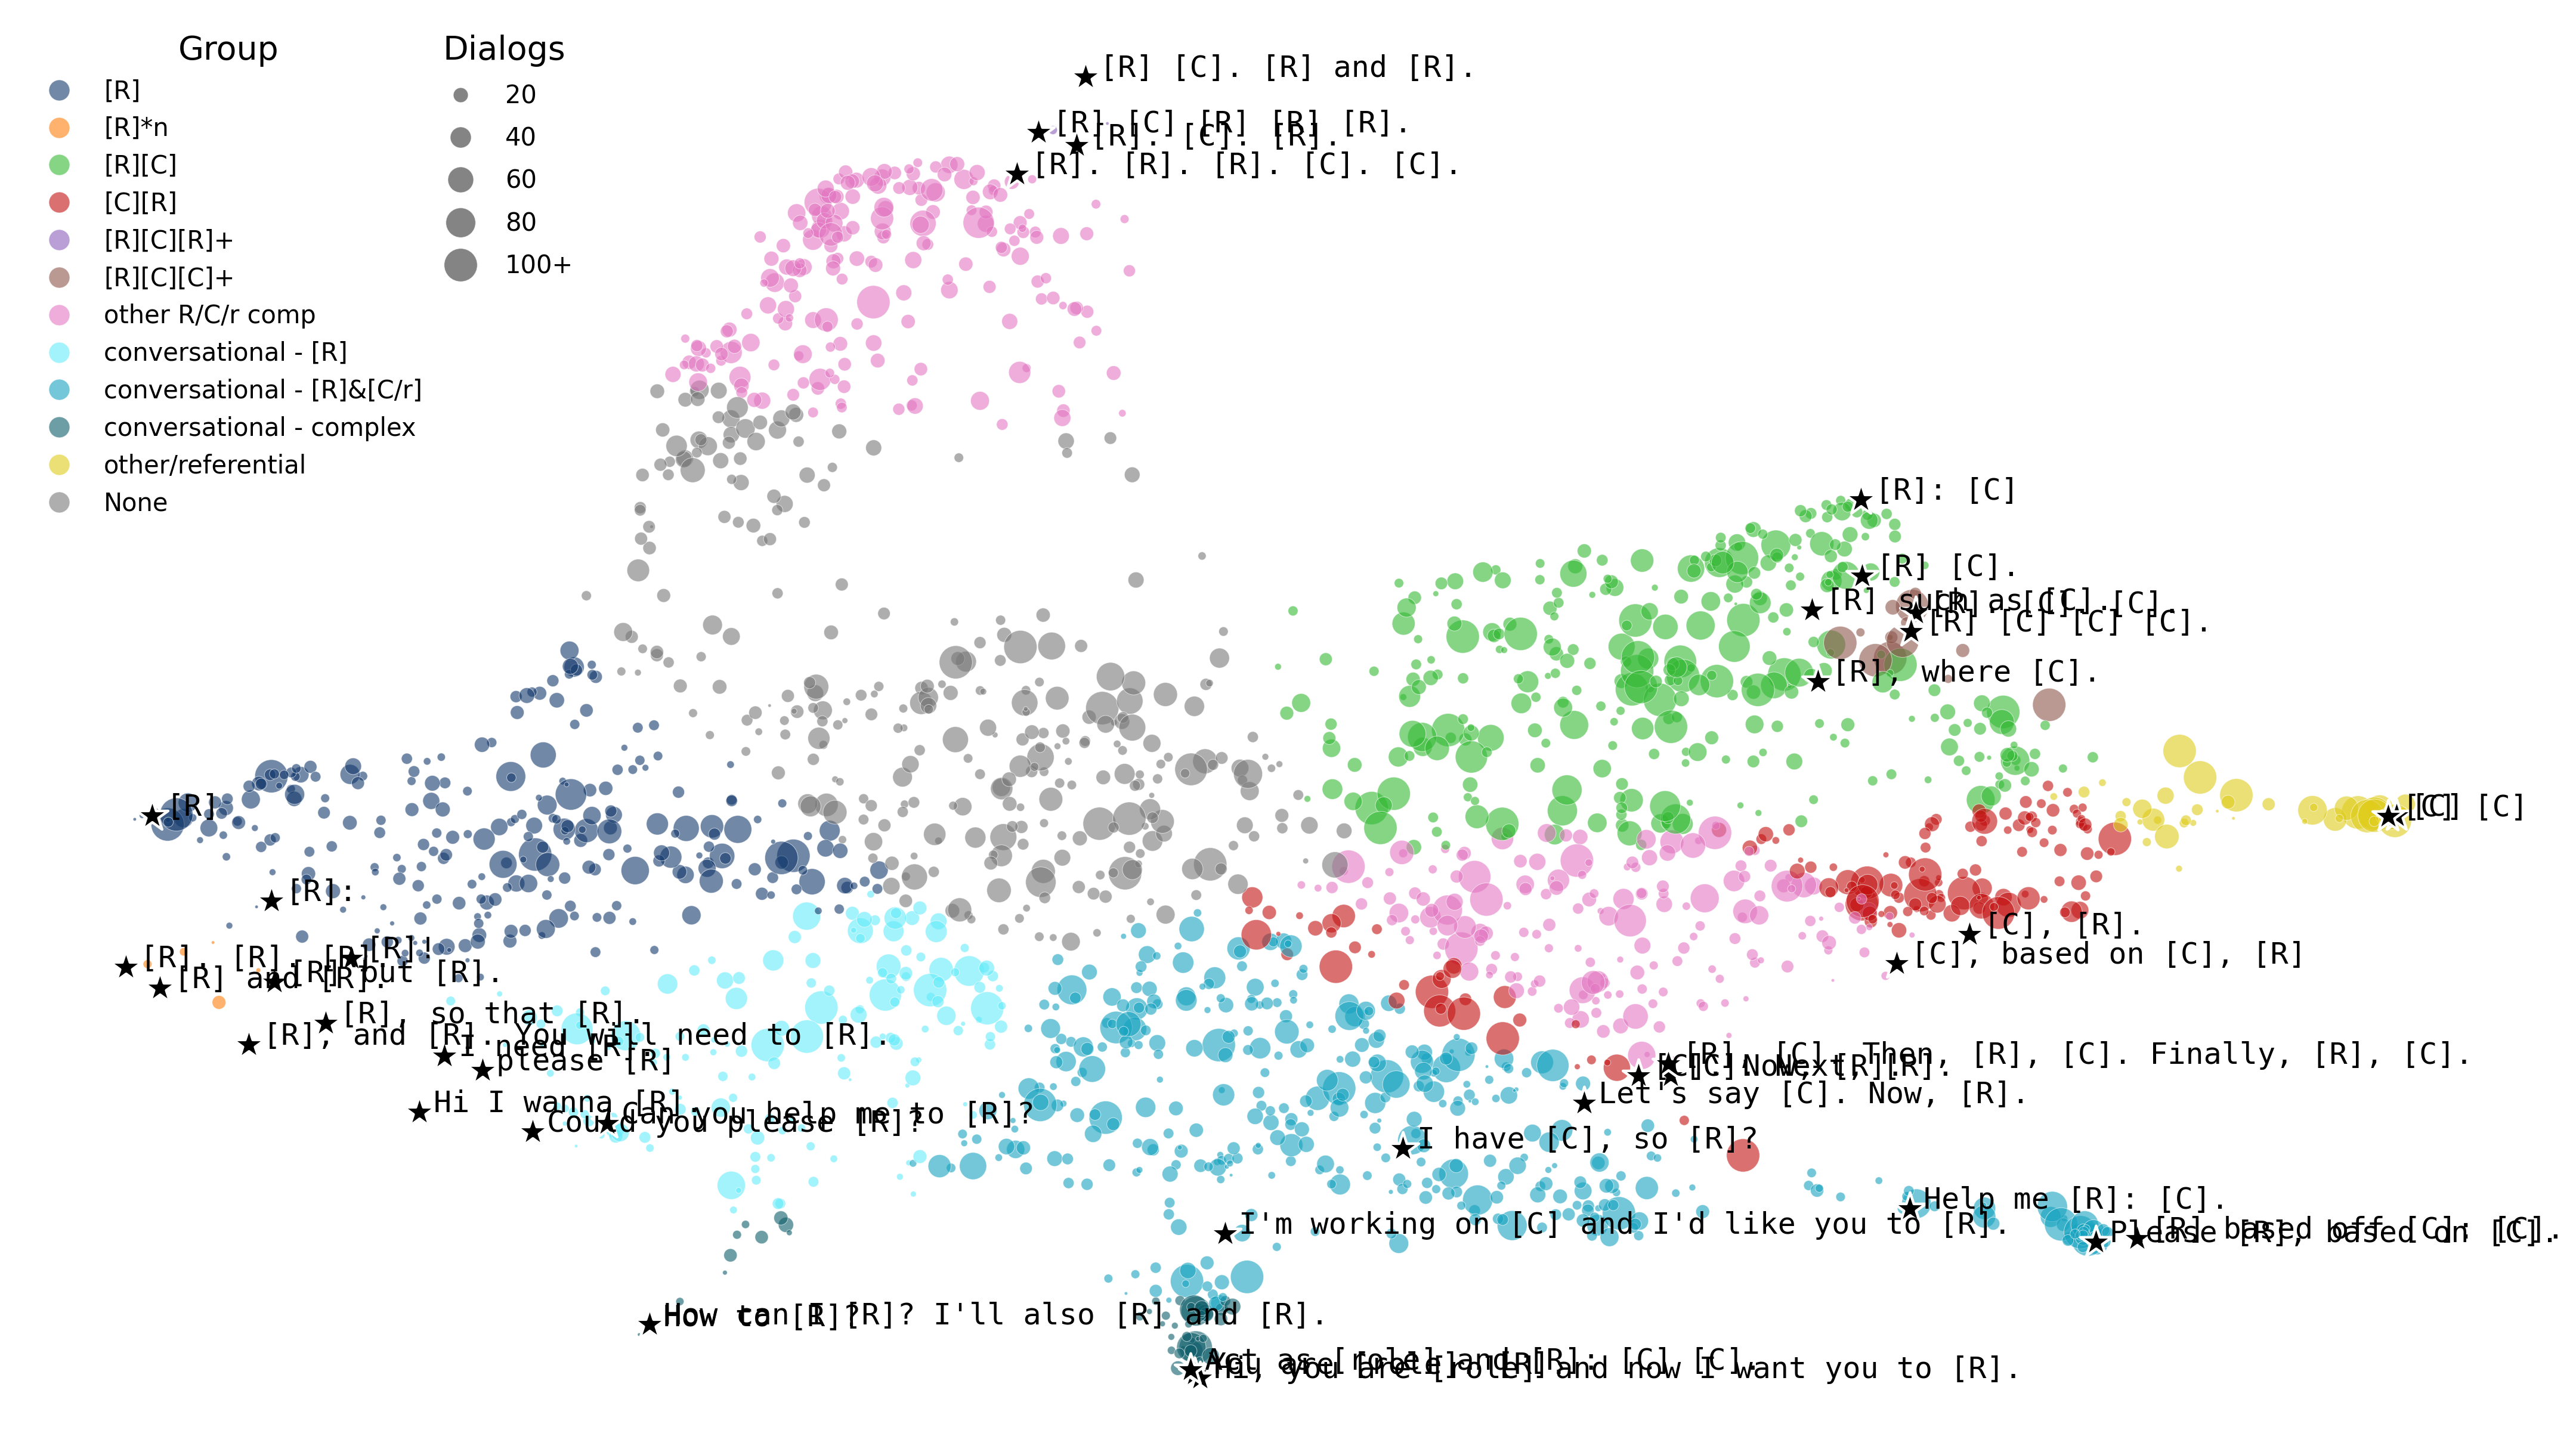

In [18]:
# Visualize the embedding

plt.figure(figsize=(22, 12), dpi=200)
hue_order = [_legends[i] for i in sorted(_legends.keys())]

jitter_strength = 0.08 # Add a bit jitter to avoid stacking in the same space
df_scatter_full = pd.DataFrame({
    'x': r_e_users[:, 0] + np.random.normal(0, jitter_strength, size=len(r_e_users)),
    'y': r_e_users[:, 1]+ np.random.normal(0, jitter_strength, size=len(r_e_users)),
    'dialogs': [min(100, item-1) for item in list(user_chat_count.values())],  # Use the dialog number of user as bubble size
    'group': [_legends[i] for i in color_groups]
})
size_min = df_scatter_full['dialogs'].min()
size_max = df_scatter_full['dialogs'].max()
print(size_min, size_max)

ax = sns.scatterplot(
    data = df_scatter_full,
    x = 'x',
    y = 'y',
    size = 'dialogs',
    size_norm=(size_min, size_max),
    sizes=(size_min*4, size_max*4),
    hue = 'group',
    hue_order = hue_order,
    palette = sns.color_palette(_12_colors),
    alpha = 0.6,
    legend = 'auto'
)

sns.scatterplot(x=r_e_selected_bases[:, 0], y=r_e_selected_bases[:, 1], s=400, c='black', marker='*')

# Comment out this for clean figure without anchor point text labels
for i, (x, y) in enumerate(r_e_selected_bases):
    plt.text(x+0.1, y, _short_baselines[i], size=18, fontfamily='monospace')

ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
labels[-1] += '+'
print(handles, labels)
_leg_hue = ax.legend(handles[1:1+len(_legends)], labels[1:1+len(_legends)], fontsize=15, labelspacing=0.5, loc='upper left', title='Group', title_fontsize=20, frameon=False, markerscale=2.1)
_leg_size = ax.legend(handles[2+len(_legends):], labels[2+len(_legends):], fontsize=15, labelspacing=0.7, loc='upper left', bbox_to_anchor=(0.16, 1), title='Dialogs', title_fontsize=20, frameon=False)
ax.add_artist(_leg_hue)

plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

#### Figure 3-1: Comparing the ReCCRE/WildChat and Stanford Politeness datasets -- percentage of expressions

In [19]:
# Directly calculate the length and percentage of remaining expressions from source dataset

def get_expr_pct(ds=ds, max_pct_thres=0.2):
    expr_pct_dict = {}
    for user in list(ds.keys()):
        user_utt_pcts = []
        for inst in ds[user]:
            expr_len = len(inst['processed_first_turn']['formatting'].replace('__[REQUEST]__', '').replace('__[CONTEXT]__', '').replace('__[ROLE]__', '').strip())
            comp_len_sum = 0
            for _coll in inst['processed_first_turn']['components'].values():
                comp_len_sum += sum([len(s) for s in list(_coll.values())])
            if expr_len + comp_len_sum > 0:
                if expr_len / (expr_len + comp_len_sum) > max_pct_thres:
                    user_utt_pcts.append(max_pct_thres)
                else:
                    user_utt_pcts.append(expr_len / (expr_len + comp_len_sum))
        if len(user_utt_pcts):
            expr_pct_dict[user] = user_utt_pcts
    
    expr_pct_col = []
    for c in list(expr_pct_dict.values()):
        expr_pct_col += c
        
    return expr_pct_col

In [20]:
# Stanford Politeness -- Wikipedia Talk

with open('datasets/stanford_politeness_dataset/processed_wiki.json', 'r', encoding='utf-8') as fb:
    stf_baseline_ds = json.load(fb)
stf_baseline_ds = [item for item in stf_baseline_ds if item['processed_first_turn'] is not None and 'performing' in item['local-annotation_type']]

stf_expr_pct_col = get_expr_pct(ds={'user': stf_baseline_ds}, max_pct_thres=1)

In [21]:
# Stanford Politeness -- Stack Exchange

with open('datasets/stanford_politeness_dataset/processed_stackEx.json', 'r', encoding='utf-8') as fb:
    stf_baseline_ds_2 = json.load(fb)
stf_baseline_ds_2 = [item for item in stf_baseline_ds_2 if item['processed_first_turn'] is not None and 'performing' in item['local-annotation_type']]

stf_expr_pct_col_2 = get_expr_pct(ds={'user': stf_baseline_ds_2}, max_pct_thres=1)

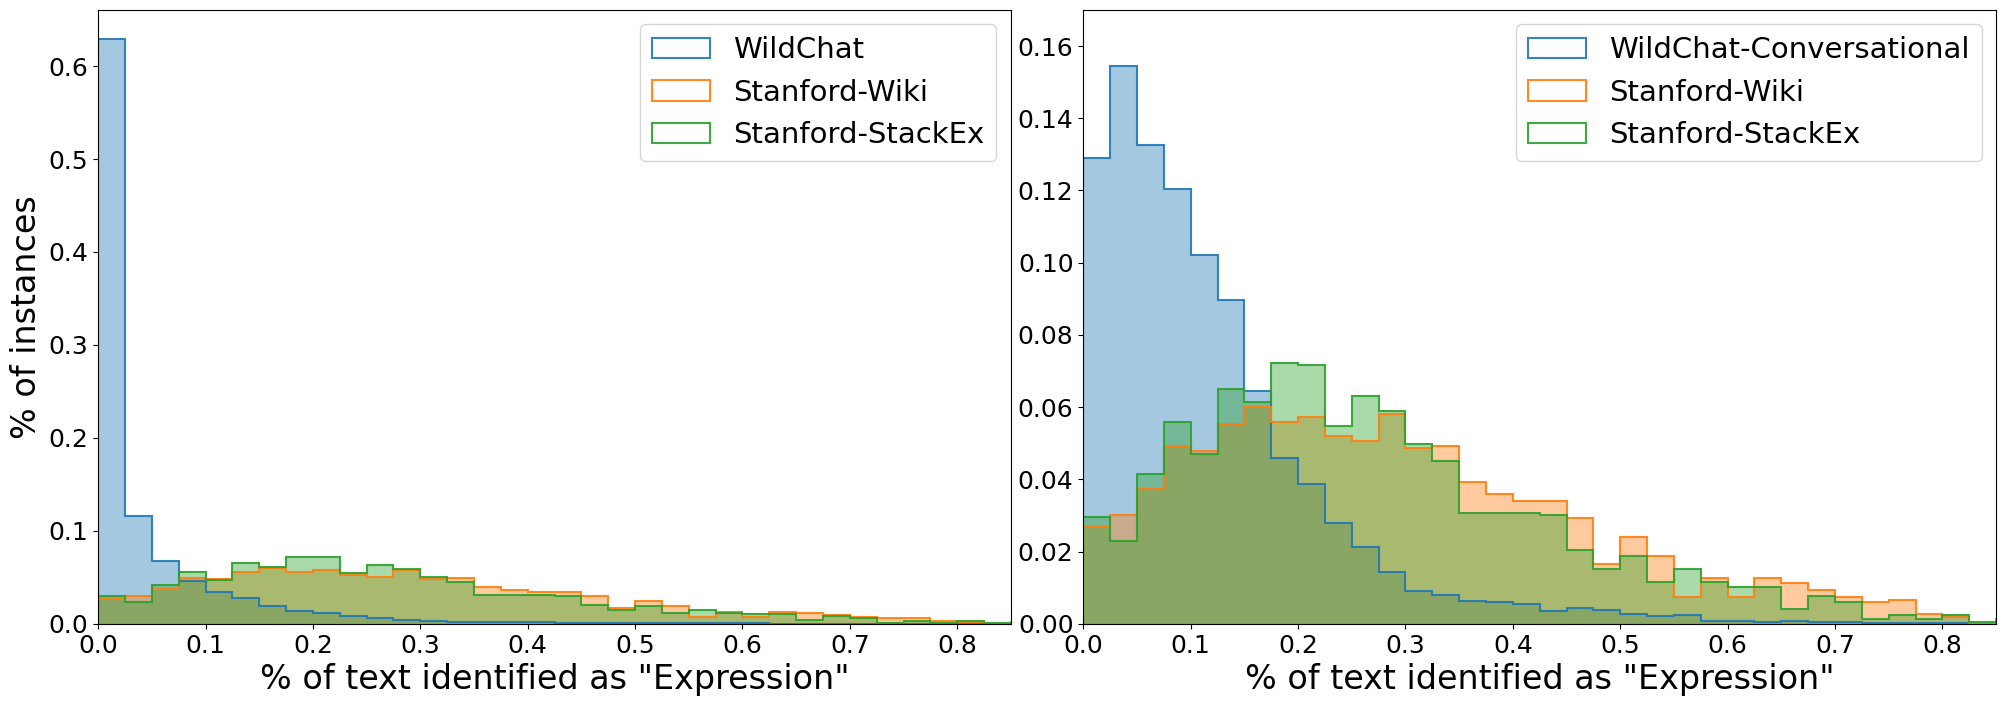

In [22]:
# Direct Comparison

expr_pct_col = get_expr_pct(ds, max_pct_thres=1)

pct_fig = plt.figure(figsize=(20,7), dpi=100)
ax1 = pct_fig.add_subplot(1, 2, 1)
plt.hist(expr_pct_col, bins=[0.025*i for i in range(40)], weights=np.ones(len(expr_pct_col)) / len(expr_pct_col), alpha=0.4, color='tab:blue')#, histtype='step')
plt.hist(expr_pct_col, bins=[0.025*i for i in range(40)], weights=np.ones(len(expr_pct_col)) / len(expr_pct_col), alpha=0.9, color='tab:blue', histtype='step', linewidth=1.5)
plt.hist(stf_expr_pct_col, bins=[0.025*i for i in range(40)], weights=np.ones(len(stf_expr_pct_col)) / len(stf_expr_pct_col), alpha=0.4, color='tab:orange')#, histtype='step')
plt.hist(stf_expr_pct_col, bins=[0.025*i for i in range(40)], weights=np.ones(len(stf_expr_pct_col)) / len(stf_expr_pct_col), alpha=0.9, color='tab:orange', histtype='step', linewidth=1.5)
plt.hist(stf_expr_pct_col_2, bins=[0.025*i for i in range(40)], weights=np.ones(len(stf_expr_pct_col_2)) / len(stf_expr_pct_col_2), alpha=0.4, color='tab:green')#, histtype='step')
plt.hist(stf_expr_pct_col_2, bins=[0.025*i for i in range(40)], weights=np.ones(len(stf_expr_pct_col_2)) / len(stf_expr_pct_col_2), alpha=0.9, color='tab:green', histtype='step', linewidth=1.5)
ax1.set_xlim(0, 0.85)
ax1.set_xticks([0.1*i for i in range(9)], [str(0.1*i)[:3] for i in range(9)], fontsize=18)
plt.yticks(fontsize=18)
ax1.set_xlabel('% of text identified as "Expression"', fontsize=24)
ax1.set_ylabel('% of instances', fontsize=24)
ax1.legend(['WildChat', 'Stanford-Wiki', 'Stanford-StackEx'], fontsize=21)


# The stronger version -- conversational only, using _ds_f collected in Figure 2 code above
# WildChat still qualitatively different from Stanford Politeness!

expr_pct_col = get_expr_pct(_ds_f, max_pct_thres=1)
ax2 = pct_fig.add_subplot(1, 2, 2)
plt.hist(expr_pct_col, bins=[0.025*i for i in range(40)], weights=np.ones(len(expr_pct_col)) / len(expr_pct_col), alpha=0.4, color='tab:blue')#, histtype='step')
plt.hist(expr_pct_col, bins=[0.025*i for i in range(40)], weights=np.ones(len(expr_pct_col)) / len(expr_pct_col), alpha=0.9, color='tab:blue', histtype='step', linewidth=1.5)
plt.hist(stf_expr_pct_col, bins=[0.025*i for i in range(40)], weights=np.ones(len(stf_expr_pct_col)) / len(stf_expr_pct_col), alpha=0.4, color='tab:orange')#, histtype='step')
plt.hist(stf_expr_pct_col, bins=[0.025*i for i in range(40)], weights=np.ones(len(stf_expr_pct_col)) / len(stf_expr_pct_col), alpha=0.9, color='tab:orange', histtype='step', linewidth=1.5)
plt.hist(stf_expr_pct_col_2, bins=[0.025*i for i in range(40)], weights=np.ones(len(stf_expr_pct_col_2)) / len(stf_expr_pct_col_2), alpha=0.4, color='tab:green')#, histtype='step')
plt.hist(stf_expr_pct_col_2, bins=[0.025*i for i in range(40)], weights=np.ones(len(stf_expr_pct_col_2)) / len(stf_expr_pct_col_2), alpha=0.9, color='tab:green', histtype='step', linewidth=1.5)
ax2.set_xlim(0, 0.85)
ax2.set_ylim(0, 0.17)
ax2.set_xticks([0.1*i for i in range(9)], [str(0.1*i)[:3] for i in range(9)], fontsize=18)
plt.yticks(fontsize=18)
ax2.set_xlabel('% of text identified as "Expression"', fontsize=24)
ax2.legend(['WildChat-Conversational', 'Stanford-Wiki', 'Stanford-StackEx'], fontsize=21)
plt.tight_layout(pad=0.5)

plt.show()

#### Figure 3-2: Comparing the ReCCRE/WildChat and Stanford Politeness datasets -- Lexical Richness (MATTR)

In [23]:
def get_lex_richness(dataset, metric='mattr', window_size=50, mtld_thres=0.72, print_user=False):
    user_mattrs = {}
    for user in dataset: # "user" can be other key attributes in the ds (e.g. month)
        if print_user:
            print(user, len(dataset[user]))
        user_input_documentation = '\n'.join([item['processed_first_turn']['formatting'] for item in dataset[user] if item['processed_first_turn']['query_type'] == 'performing tasks'])
        user_input_documentation = user_input_documentation.replace('__[REQUEST]__', ' dddREQUESTbbb ').replace('__[CONTEXT]__', ' dddRCONTEXTbbb ').replace('__[ROLE]__', ' dddROLEbbb ') # Create a definitely unique token for calculation
        lex = LexicalRichness(user_input_documentation)
        try:
            if metric == 'mattr':
                user_mattrs[user] = lex.mattr(window_size=min(window_size, lex.words))
            elif metric == 'mtld':
                user_mattrs[user] = lex.mtld(mtld_thres)
            elif metric == 'hdd':
                user_mattrs[user] = lex.hdd()
            else:
                print("Invalid metric!")
                return -1
        except:
            continue
    return user_mattrs 

In [24]:
# Filter other datasets (Stanford) to similarly include only the "performing tasks" type

def format_other_ds(ds_by_user, sort_input=True):
    filtered_ds = {}
    for user in ds_by_user:
        insts = ds_by_user[user]
        if sort_input:
            insts = sorted(ds_by_user[user], key=lambda item: item['conversation_metadata']['timestamp'])
        insts = [inst for inst in insts if inst['processed_first_turn'] is not None and inst['processed_first_turn']['query_type'] == 'performing tasks']
        if len(insts) <= 1:
            continue
        filtered_ds[user] = insts
        
    return filtered_ds

In [25]:
# Stanford Politeness dataset doesn't have ground-truth speaker IDs;
# For MATTR computation and fair comparison, we simulate attributing the speakers using the same distribution of ReCCRE

# 1. Extract the distribution of ReCCRE
utt_num_col = [len(ds[user]) for user in ds if len(ds[user])<=200]
print(np.median(utt_num_col))
shape_est, loc_est, scale_est = stats.gamma.fit(utt_num_col, floc=0)

14.0


In [26]:
# 2. Simulate the same distribution on Stanford and randomly sample from the data for each user

def simulate_user_sampling(base_ds, shape_est=shape_est, scale_est=scale_est):
    
    sim_data = stats.gamma.rvs(shape_est, scale=scale_est, loc=loc_est, size=1000)
    sim_data = [math.ceil(item) for item in sim_data]
    
    random.shuffle(base_ds)

    stf_sim_users = {}
    tot_num = 0
    for i, num in enumerate(sim_data):
        sim_user_utts = base_ds[tot_num:tot_num+num]
        stf_sim_users[i] = sim_user_utts
        tot_num += num
        if tot_num >= len(base_ds):
            break

    stf_sim_users = format_other_ds(stf_sim_users, sort_input=False)
    stf_mattrs = get_lex_richness(stf_sim_users, print_user=False)

    return stf_mattrs

100%|██████████| 10/10 [00:00<00:00, 13.57it/s]


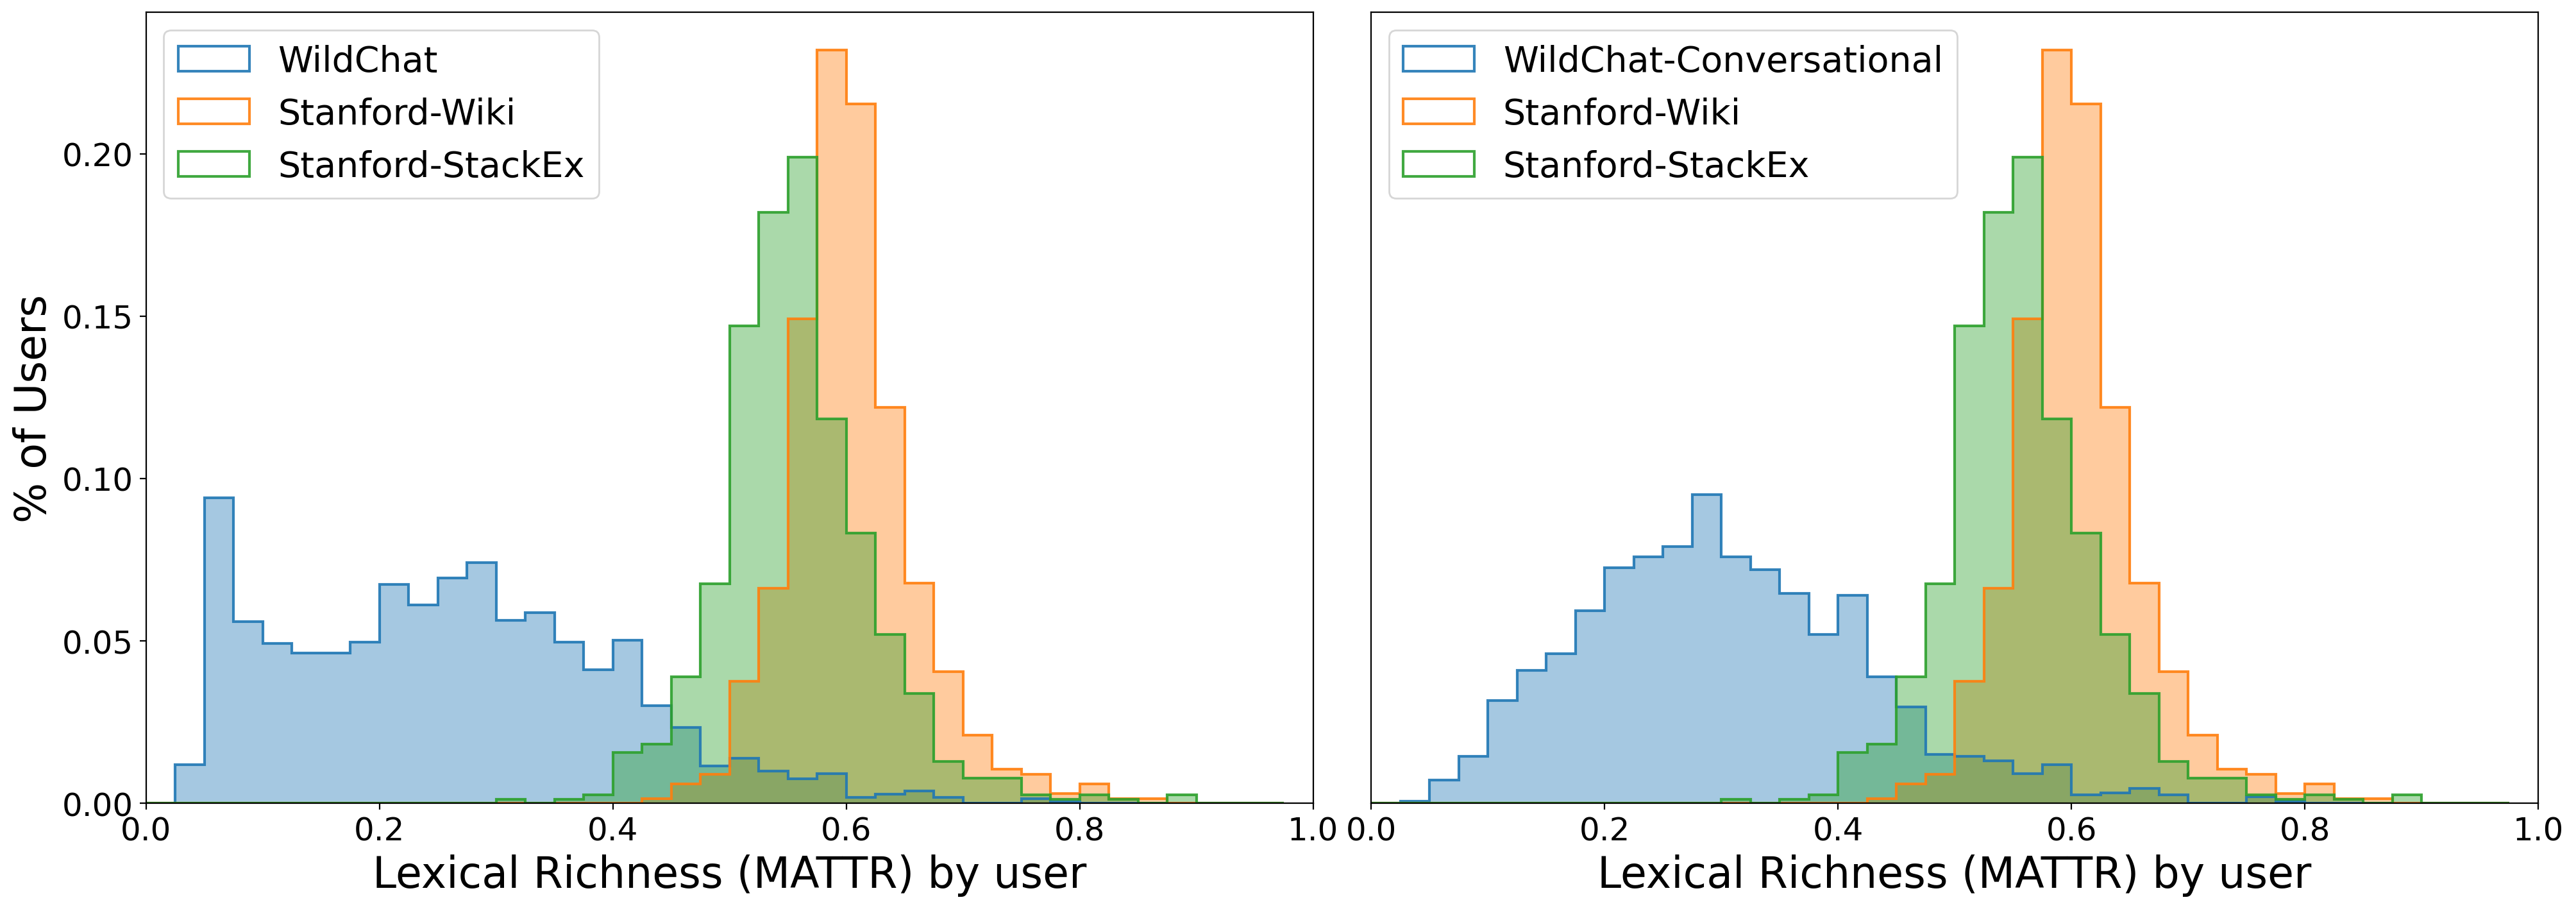

In [27]:
# Full ReCCRE
user_mattrs = {}
for user in ds:
    user_input_documentation = '\n'.join([item['processed_first_turn']['formatting'] for item in ds[user] if item['processed_first_turn']['query_type'] == 'performing tasks'])
    user_input_documentation = user_input_documentation.replace('__[REQUEST]__', ' dddREQUESTbbb ').replace('__[CONTEXT]__', ' dddRCONTEXTbbb ').replace('__[ROLE]__', ' dddROLEbbb ')
    lex = LexicalRichness(user_input_documentation)
    try:
        user_mattrs[user] = lex.mattr(window_size=min(50, lex.words))
    except:
        continue 
_user = [user_mattrs[uid] for uid in user_mattrs]

# Stanford datasets
_stf_wiki_sim, _stf_stackEx_sim = [], []
for i in tqdm(range(10)):
    stf_wiki_mattrs_sim = simulate_user_sampling(stf_baseline_ds)
    stf_stackEx_mattrs_sim = simulate_user_sampling(stf_baseline_ds_2)
    _stf_wiki_sim += [stf_wiki_mattrs_sim[uid] for uid in stf_wiki_mattrs_sim]
    _stf_stackEx_sim += [stf_stackEx_mattrs_sim[uid] for uid in stf_stackEx_mattrs_sim]
    
mattr_fig = plt.figure(figsize=(20,7), dpi=200)
ax1 = mattr_fig.add_subplot(1, 2, 1)
plt.hist(_user, histtype='bar', bins=[0.025*i for i in range(40)], weights=np.ones(len(_user)) / len(_user), alpha=0.4, color='tab:blue')
plt.hist(_user, histtype='step', bins=[0.025*i for i in range(40)], weights=np.ones(len(_user)) / len(_user), alpha=0.9, color='tab:blue', linewidth=1.5)
plt.hist(_stf_wiki_sim, histtype='bar', bins=[0.025*i for i in range(40)], weights=np.ones(len(_stf_wiki_sim)) / len(_stf_wiki_sim), alpha=0.4, color='tab:orange')
plt.hist(_stf_wiki_sim, histtype='step', bins=[0.025*i for i in range(40)], weights=np.ones(len(_stf_wiki_sim)) / len(_stf_wiki_sim), alpha=0.9, color='tab:orange', linewidth=1.5)
plt.hist(_stf_stackEx_sim, histtype='bar', bins=[0.025*i for i in range(40)], weights=np.ones(len(_stf_stackEx_sim)) / len(_stf_stackEx_sim), alpha=0.4, color='tab:green')
plt.hist(_stf_stackEx_sim, histtype='step', bins=[0.025*i for i in range(40)], weights=np.ones(len(_stf_stackEx_sim)) / len(_stf_stackEx_sim), alpha=0.9, color='tab:green', linewidth=1.5)
ax1.set_xlim(0.0, 1.0)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
ax1.set_xlabel('Lexical Richness (MATTR) by user', fontsize=24)
ax1.set_ylabel('% of Users', fontsize=24)
ax1.legend(['WildChat', 'Stanford-Wiki', 'Stanford-StackEx'], fontsize=20)


# The stronger version -- conversational only, using _ds_f collected in Figure 2 code above
# WildChat still qualitatively different from Stanford Politeness!
user_mattrs = {}
for user in _ds_f:
    user_input_documentation = '\n'.join([item['processed_first_turn']['formatting'] for item in ds[user] if item['processed_first_turn']['query_type'] == 'performing tasks'])
    user_input_documentation = user_input_documentation.replace('__[REQUEST]__', ' dddREQUESTbbb ').replace('__[CONTEXT]__', ' dddRCONTEXTbbb ').replace('__[ROLE]__', ' dddROLEbbb ')
    lex = LexicalRichness(user_input_documentation)
    try:
        user_mattrs[user] = lex.mattr(window_size=min(50, lex.words))
    except:
        continue
_user = [user_mattrs[uid] for uid in user_mattrs]

# Again, compare with Stanford
ax2 = mattr_fig.add_subplot(1, 2, 2)
plt.hist(_user, histtype='bar', bins=[0.025*i for i in range(40)], weights=np.ones(len(_user)) / len(_user), alpha=0.4, color='tab:blue')
plt.hist(_user, histtype='step', bins=[0.025*i for i in range(40)], weights=np.ones(len(_user)) / len(_user), alpha=0.9, color='tab:blue', linewidth=1.5)
plt.hist(_stf_wiki_sim, histtype='bar', bins=[0.025*i for i in range(40)], weights=np.ones(len(_stf_wiki_sim)) / len(_stf_wiki_sim), alpha=0.4, color='tab:orange')
plt.hist(_stf_wiki_sim, histtype='step', bins=[0.025*i for i in range(40)], weights=np.ones(len(_stf_wiki_sim)) / len(_stf_wiki_sim), alpha=0.9, color='tab:orange', linewidth=1.5)
plt.hist(_stf_stackEx_sim, histtype='bar', bins=[0.025*i for i in range(40)], weights=np.ones(len(_stf_stackEx_sim)) / len(_stf_stackEx_sim), alpha=0.4, color='tab:green')
plt.hist(_stf_stackEx_sim, histtype='step', bins=[0.025*i for i in range(40)], weights=np.ones(len(_stf_stackEx_sim)) / len(_stf_stackEx_sim), alpha=0.9, color='tab:green', linewidth=1.5)
ax2.set_xlim(0.0, 1.0)
plt.xticks(fontsize=18)
ax2.set_yticks([])
ax2.set_xlabel('Lexical Richness (MATTR) by user', fontsize=24)
plt.legend(['WildChat-Conversational', 'Stanford-Wiki', 'Stanford-StackEx'], fontsize=20)
plt.tight_layout(pad=0.4)
plt.show()

#### Figure 6: Within-user convergence of expressions over time

In [28]:
# Comparing the distances of current session input with the same user's previous (window_size) sessions

def compute_dists_with_prev(ds=ds, window_size=1, sort_timestamp=True, max_chat_num=18, collect_remaining=True, use_tqdm=True):
    dists_col = []
    
    iter = tqdm(ds) if use_tqdm else ds
    for user in iter:
        dists = []
        requests = [item for item in ds[user] if item['processed_first_turn']['query_type'] == 'performing tasks']
        if sort_timestamp:
            requests.sort(key=lambda item: item['conversation_metadata']['timestamp'])

        # Loop through the previous window_size sessions and find minimal cosine distance
        for i in range(window_size, len(requests)):
            min_sim = 1.0
            if window_size > 0:
                search_ids = range(max(0, i-window_size), i)
            else:
                search_ids = range(0, i)
            for j in search_ids:
                _sim = float(cdist(requests[j]['processed_first_turn']['encoded_formatting'], requests[i]['processed_first_turn']['encoded_formatting'], metric='cosine').squeeze())
                if _sim < min_sim:
                    min_sim = _sim
            dists.append(min_sim)
        dists_col.append(dists)
        
    _d_prev_chats = []
    for i in range(max_chat_num+1):
        _cols = [dists[i] for dists in dists_col if len(dists)>i]
        _d_prev_chats.append(np.mean(_cols))
        
    if collect_remaining: # Collect the remaining sessions > max_chat_num as one bin for visualization
        _final_bin = []
        for dists in dists_col:
            for i in range(max_chat_num+1, len(dists)):
                _final_bin.append(dists[i])
        _d_prev_chats.append(np.mean(_final_bin))
    
    return _d_prev_chats

In [29]:
def plot_cosine_diff_evo(window_size=1, manual_ylim=None, random_trials=50, figsize=(10,8), dpi=100):
    plt.figure(figsize=figsize, dpi=dpi)
    plt.title(f'W = {window_size}', fontsize=24)
    avg_dist_with_prev = compute_dists_with_prev(ds, window_size=window_size, max_chat_num=19-window_size)
    if window_size==1:
        plt.plot(avg_dist_with_prev, linewidth=3)
    else: # Smoothen with Exponential Moving Average to reduce local fluctuation
        avg_dist_with_prev = pd.DataFrame({'dist': avg_dist_with_prev})
        ema = avg_dist_with_prev.ewm(span=3, min_periods=1).mean()
        plt.plot(ema, linewidth=3)
        
    # Compare with the shuffled baselines
    shuffled_col = []
    for t in tqdm(range(random_trials)):
        ds_shuffled = {}
        for _uid in ds:
            ds_shuffled[_uid] = random.sample(list(ds[_uid]), len(ds[_uid]))
        shuffled_avg_dist_with_prev = compute_dists_with_prev(ds=ds_shuffled, sort_timestamp=False, window_size=window_size, max_chat_num=19-window_size, use_tqdm=False)
        if window_size == 1:
            plt.plot(shuffled_avg_dist_with_prev, color='gray', alpha=0.12, linewidth=1)
            shuffled_col.append(shuffled_avg_dist_with_prev)
        else:
            shuffled_avg_dist_with_prev = pd.DataFrame({'dist': shuffled_avg_dist_with_prev})
            shuffled_ema = shuffled_avg_dist_with_prev.ewm(span=3, min_periods=1).mean()
            plt.plot(shuffled_ema, color='gray', alpha=0.12, linewidth=1)
            shuffled_col.append(shuffled_ema)
    shuffled_col = np.mean(shuffled_col, axis=0) # Overall as the bold orange line
    plt.plot(shuffled_col, linewidth=3)
    if manual_ylim:
        plt.ylim(manual_ylim[0], manual_ylim[1])
    plt.xticks(np.arange(21-window_size), [str(i) for i in np.arange(window_size, 20)] + ['20+'])
    plt.xlabel("i", fontsize=15)
    plt.ylabel('Avg. cosine difference with i-th post', fontsize=16)
    plt.tight_layout(pad=0.05)
    plt.show()

  7%|▋         | 156/2092 [00:00<00:01, 1495.80it/s]

100%|██████████| 50/50 [00:34<00:00,  1.43it/s]


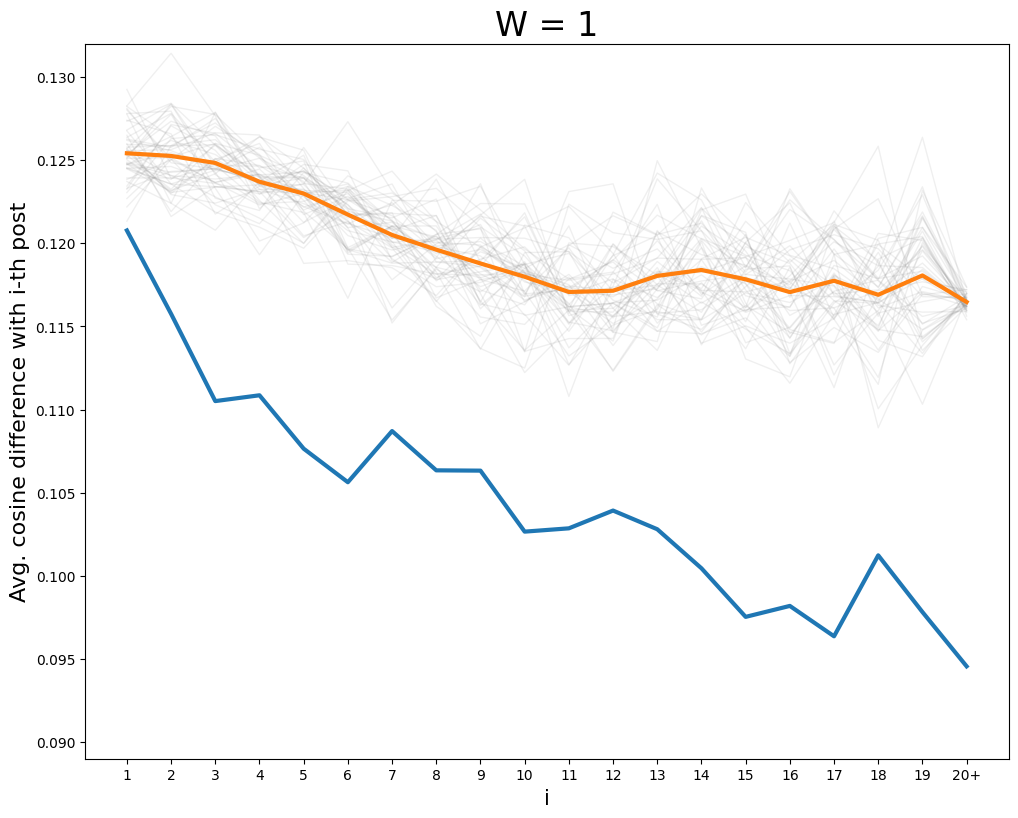

In [30]:
plot_cosine_diff_evo(window_size=1, manual_ylim=(0.089, 0.132))

  7%|▋         | 147/2092 [00:00<00:02, 766.36it/s]

100%|██████████| 50/50 [01:22<00:00,  1.65s/it]


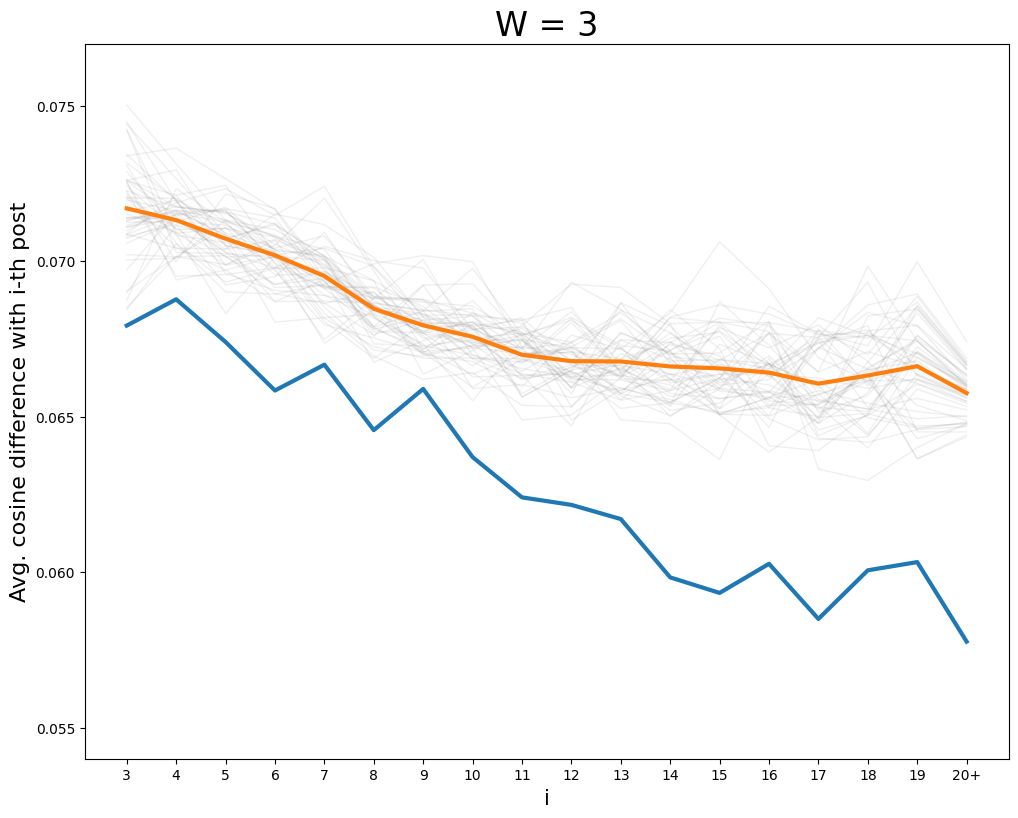

In [31]:
plot_cosine_diff_evo(window_size=3, manual_ylim=(0.054, 0.077))

  5%|▍         | 101/2092 [00:00<00:04, 488.59it/s]

100%|██████████| 50/50 [02:01<00:00,  2.43s/it]


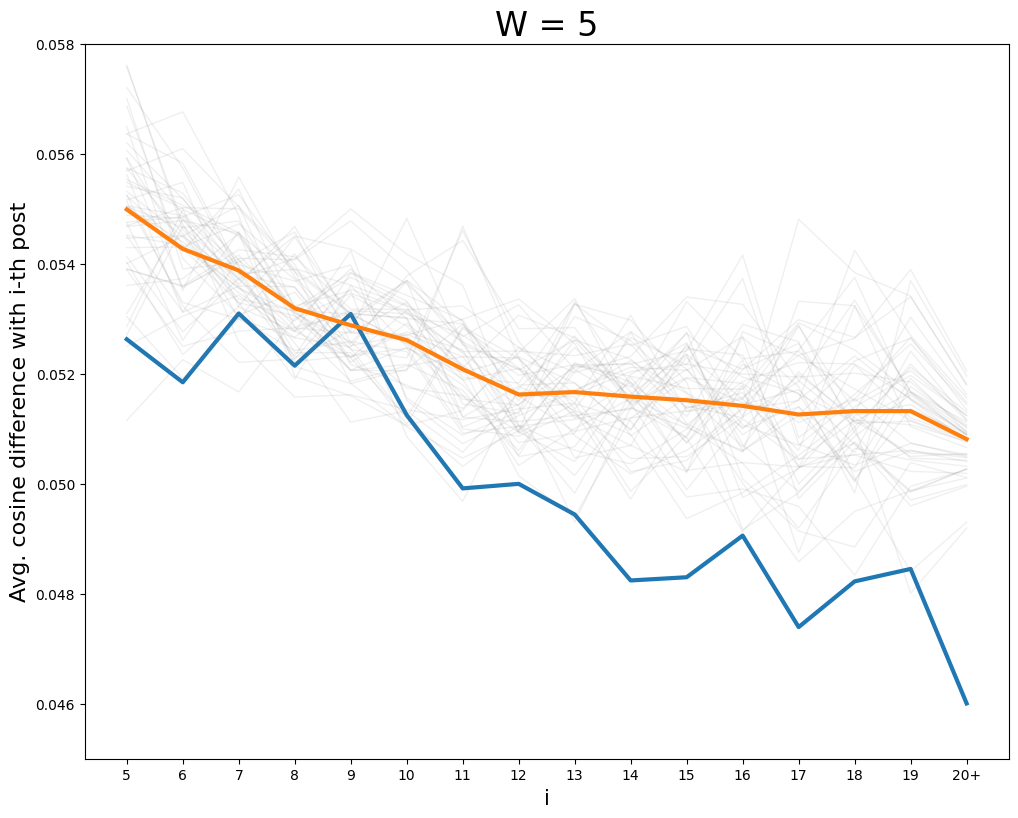

In [32]:
plot_cosine_diff_evo(window_size=5, manual_ylim=(0.045, 0.058))

#### Figure 4 & 5: Early vs. Late: Distribution of the 1st (left) and 20th dialog expressions, in the same 2-D space of Figure 2

In [33]:
early_reps, later_reps = {}, {}
for user in user_reps_col:
    req_embeds = user_reps_col[user]
    if len(req_embeds) > 19:
        early_reps[user] = req_embeds[0]
        later_reps[user] = req_embeds[19]
early_concat = np.concatenate(list(early_reps.values()), axis=0)
later_concat = np.concatenate(list(later_reps.values()), axis=0)
print(early_concat.shape, later_concat.shape)
_user_num = early_concat.shape[0]

(713, 1024) (713, 1024)


In [34]:
user_comparison_concat = np.concatenate((early_concat, later_concat), axis=0)
reduced_embeds = space.transform(user_comparison_concat, basis=user_avg_concat) # Reuse the previous 2D space
print(reduced_embeds.shape)

(1426, 2)


In [35]:
reduced_embeds_alt = rotate(reduced_embeds, _angle)
r_early = reduced_embeds_alt[:_user_num]
r_later = reduced_embeds_alt[_user_num:2*_user_num]
print(r_early.shape, r_later.shape)

(713, 2) (713, 2)


In [36]:
from matplotlib.colors import TwoSlopeNorm

def plot_kde_difference(data1, data2, anchor_pos=r_e_selected_bases, anchor_label=_short_baselines, 
                                figsize=(15, 10), dpi=200, cmap='RdBu_r', 
                                bw_method='scott', levels=15, save_figures=False):

    # Get bounds
    x_min = min(data1[:, 0].min(), data2[:, 0].min())-4.5
    x_max = max(data1[:, 0].max(), data2[:, 0].max())+3.5
    y_min = min(data1[:, 1].min(), data2[:, 1].min())-4
    y_max = max(data1[:, 1].max(), data2[:, 1].max())+4
    
    
    # Figure 1: first input dataset
    fig1 = plt.figure(figsize=(figsize[0], 2*figsize[1]), dpi=dpi)
    ax1 = fig1.add_subplot(211)
    sns.kdeplot(x=data1[:, 0], y=data1[:, 1], 
                ax=ax1, cmap='Blues', fill=True, levels=levels,
                bw_method=bw_method)
    sns.scatterplot(x=anchor_pos[:, 0], y=anchor_pos[:, 1], s=120, c='black', marker='*')
    ax1.set_title('Early KDE', fontsize=20, pad=15)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.set_xticks([])
    ax1.set_yticks([])
    fig1.tight_layout(pad=5.4)
    
    
    # Figure 2: the other input dataset
    ax2 = fig1.add_subplot(212)
    sns.kdeplot(x=data2[:, 0], y=data2[:, 1], 
                ax=ax2, cmap='Oranges', fill=True, levels=levels,
                bw_method=bw_method)
    sns.scatterplot(x=anchor_pos[:, 0], y=anchor_pos[:, 1], s=120, c='black', marker='*')
    ax2.set_title('Late KDE', fontsize=20, pad=15)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    ax2.set_xticks([])
    ax2.set_yticks([])
    
    
    # Figure 3: Plot difference as heatmap
    _x, _y = figsize
    fig3 = plt.figure(figsize=(_x, _y*1.06), dpi=dpi)
    ax3 = fig3.add_subplot(111)
    
    # Compute KDEs with same bandwidth method
    kde1 = stats.gaussian_kde(data1.T, bw_method=bw_method)
    kde2 = stats.gaussian_kde(data2.T, bw_method=bw_method)
    
    # Create evaluation grid
    x = np.linspace(x_min, x_max, 100)
    y = np.linspace(y_min, y_max, 100)
    xx, yy = np.meshgrid(x, y)
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    # Evaluate and compute difference
    z1 = kde1(positions).reshape(xx.shape)
    z2 = kde2(positions).reshape(xx.shape)
    diff = z2 - z1
    
    # Use TwoSlopeNorm for better control over colorbar centering
    norm = TwoSlopeNorm(vmin=diff.min(), vcenter=0, vmax=diff.max())
    
    # Plot difference
    contour = ax3.contourf(xx, yy, diff, levels=int(levels*1.34), cmap=cmap, norm=norm)
    ax3.contour(xx, yy, diff, levels=[0], colors='grey', 
                linewidths=1, linestyles='--')
    sns.scatterplot(x=anchor_pos[:, 0], y=anchor_pos[:, 1], s=120, c='black', marker='*')
    
    ax3.set_title('KDE Difference between early- and late-stage dialogs', fontsize=20, pad=10)
    ax3.set_xlim(x_min, x_max)
    ax3.set_ylim(y_min, y_max)
    ax3.set_xticks([])
    ax3.set_yticks([])
    
    cbar = plt.colorbar(contour, ax=ax3, orientation='horizontal', pad=0.01, aspect=50)
    cbar.set_label('Density Difference', fontsize=16)
    fig3.tight_layout(pad=0.1)
    fig3.subplots_adjust(bottom=0)
    
    return fig1, fig3

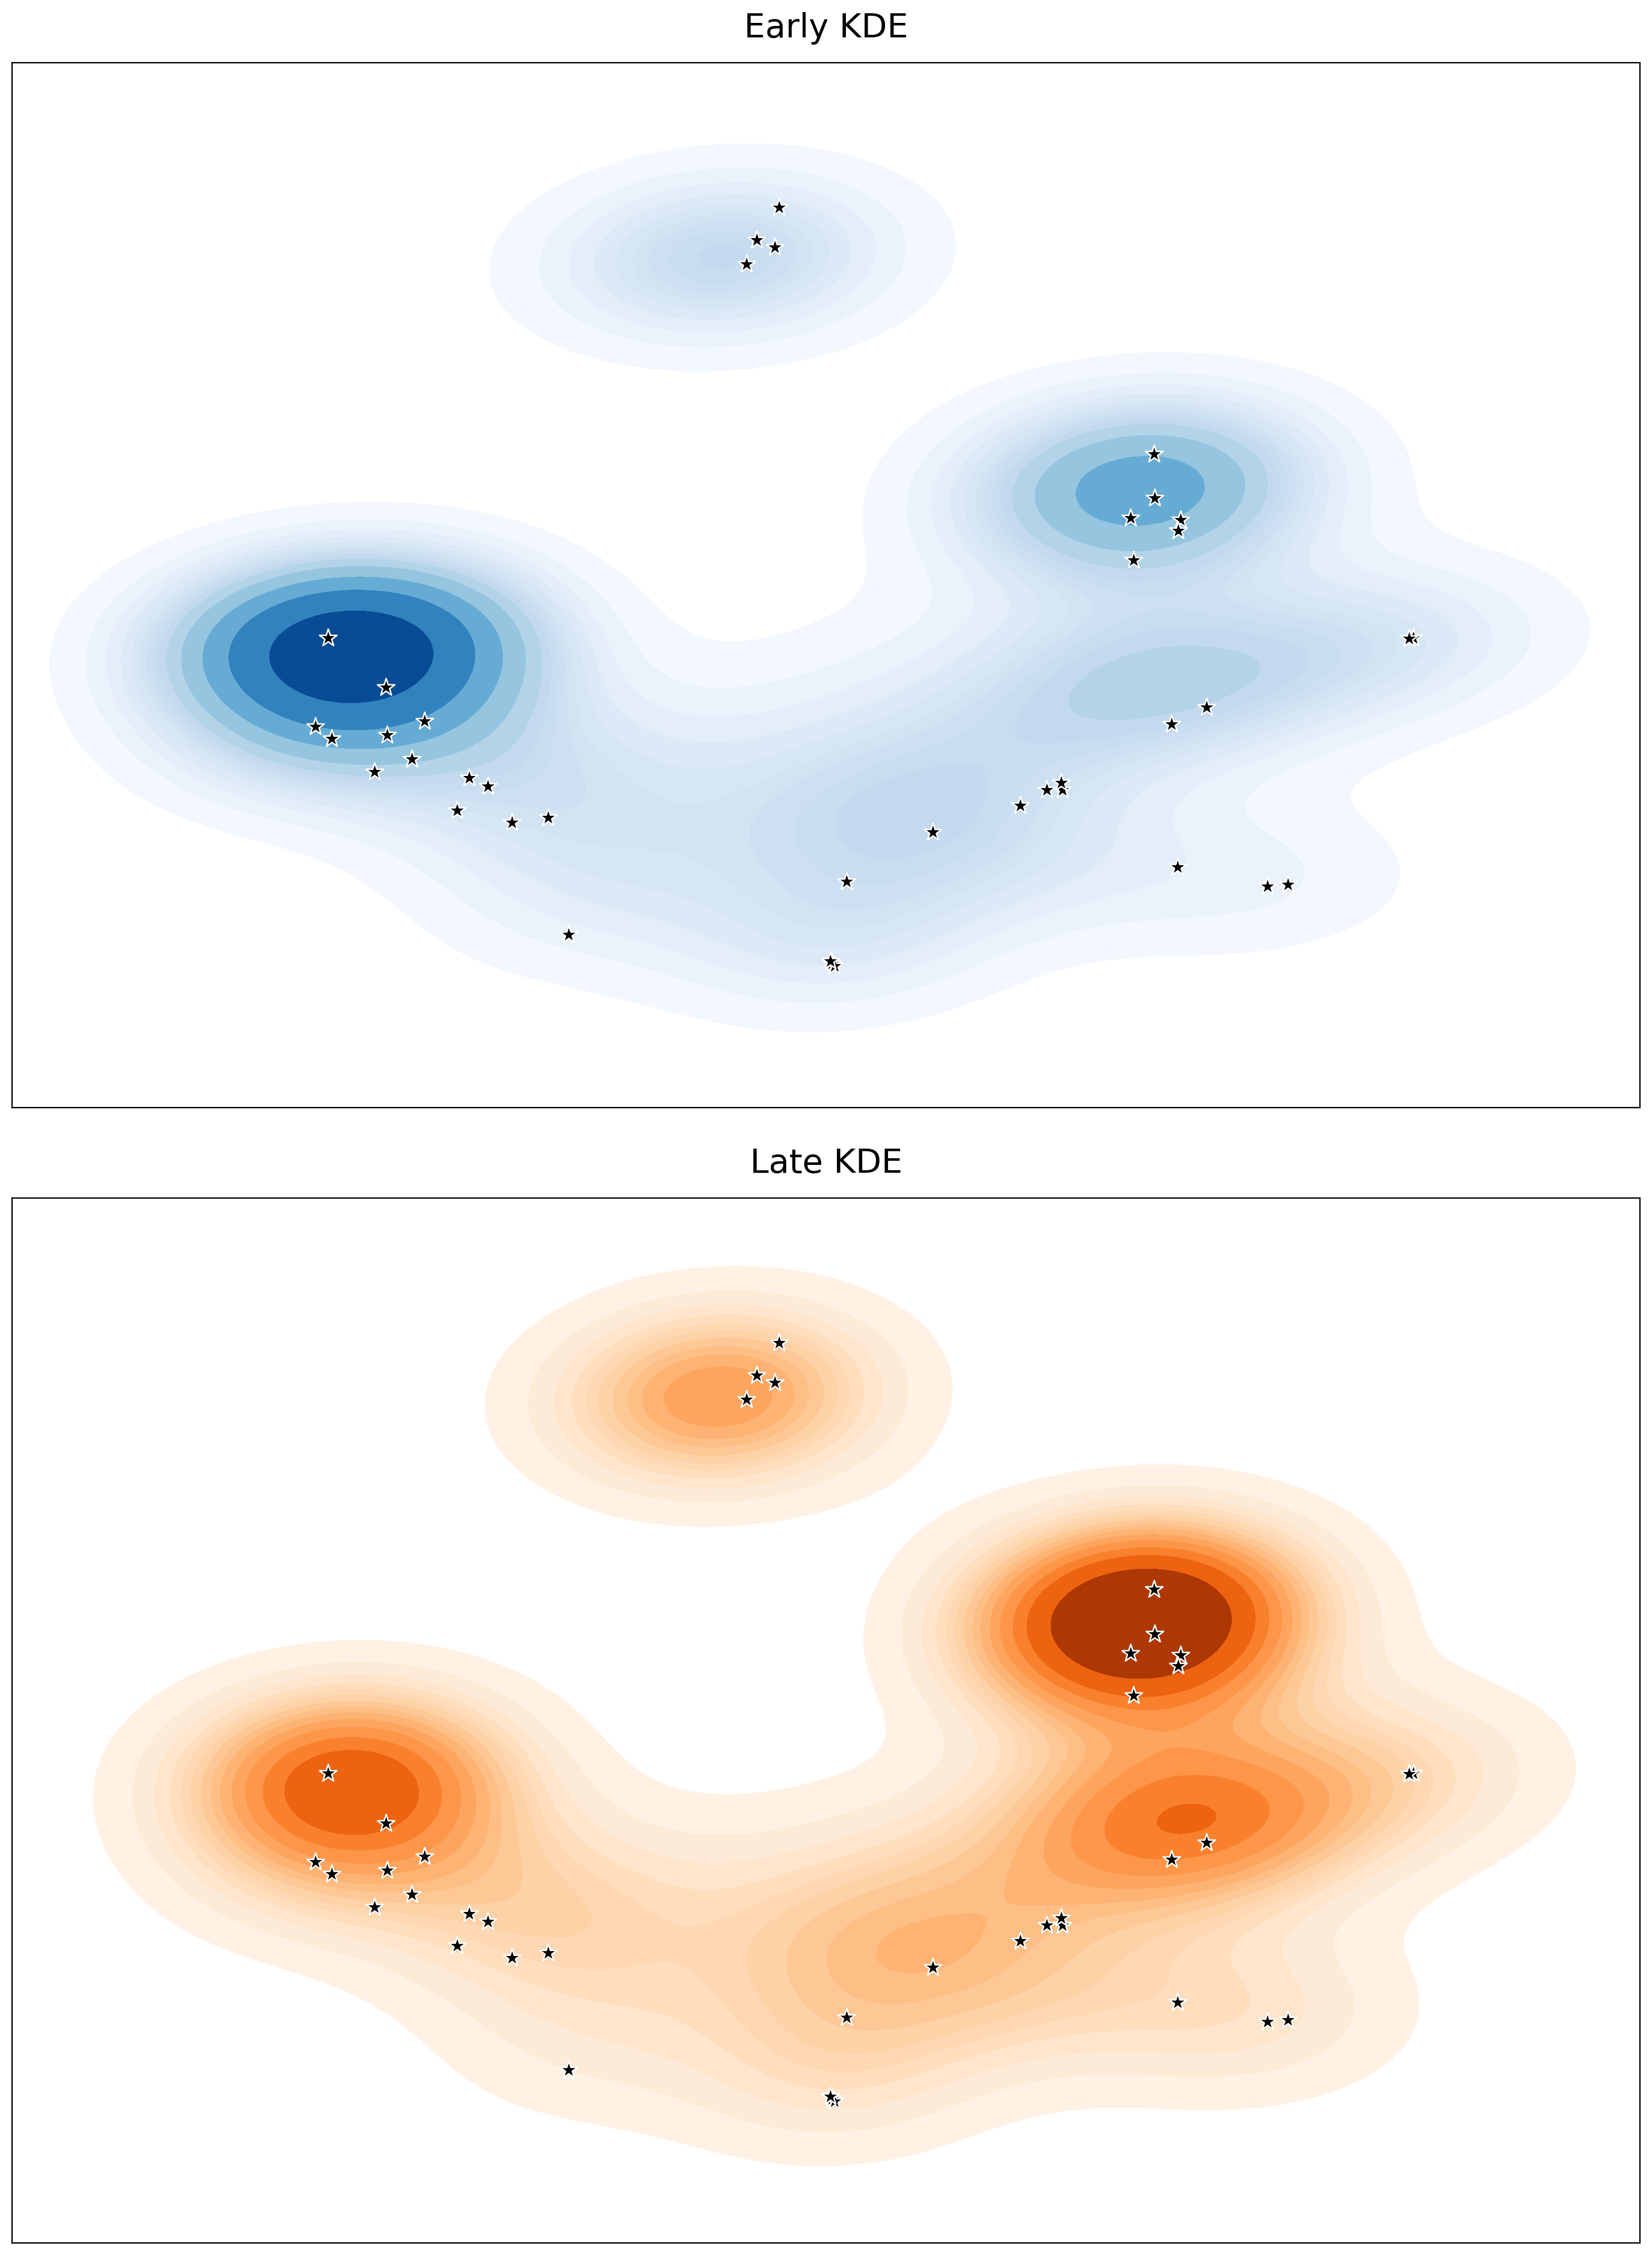

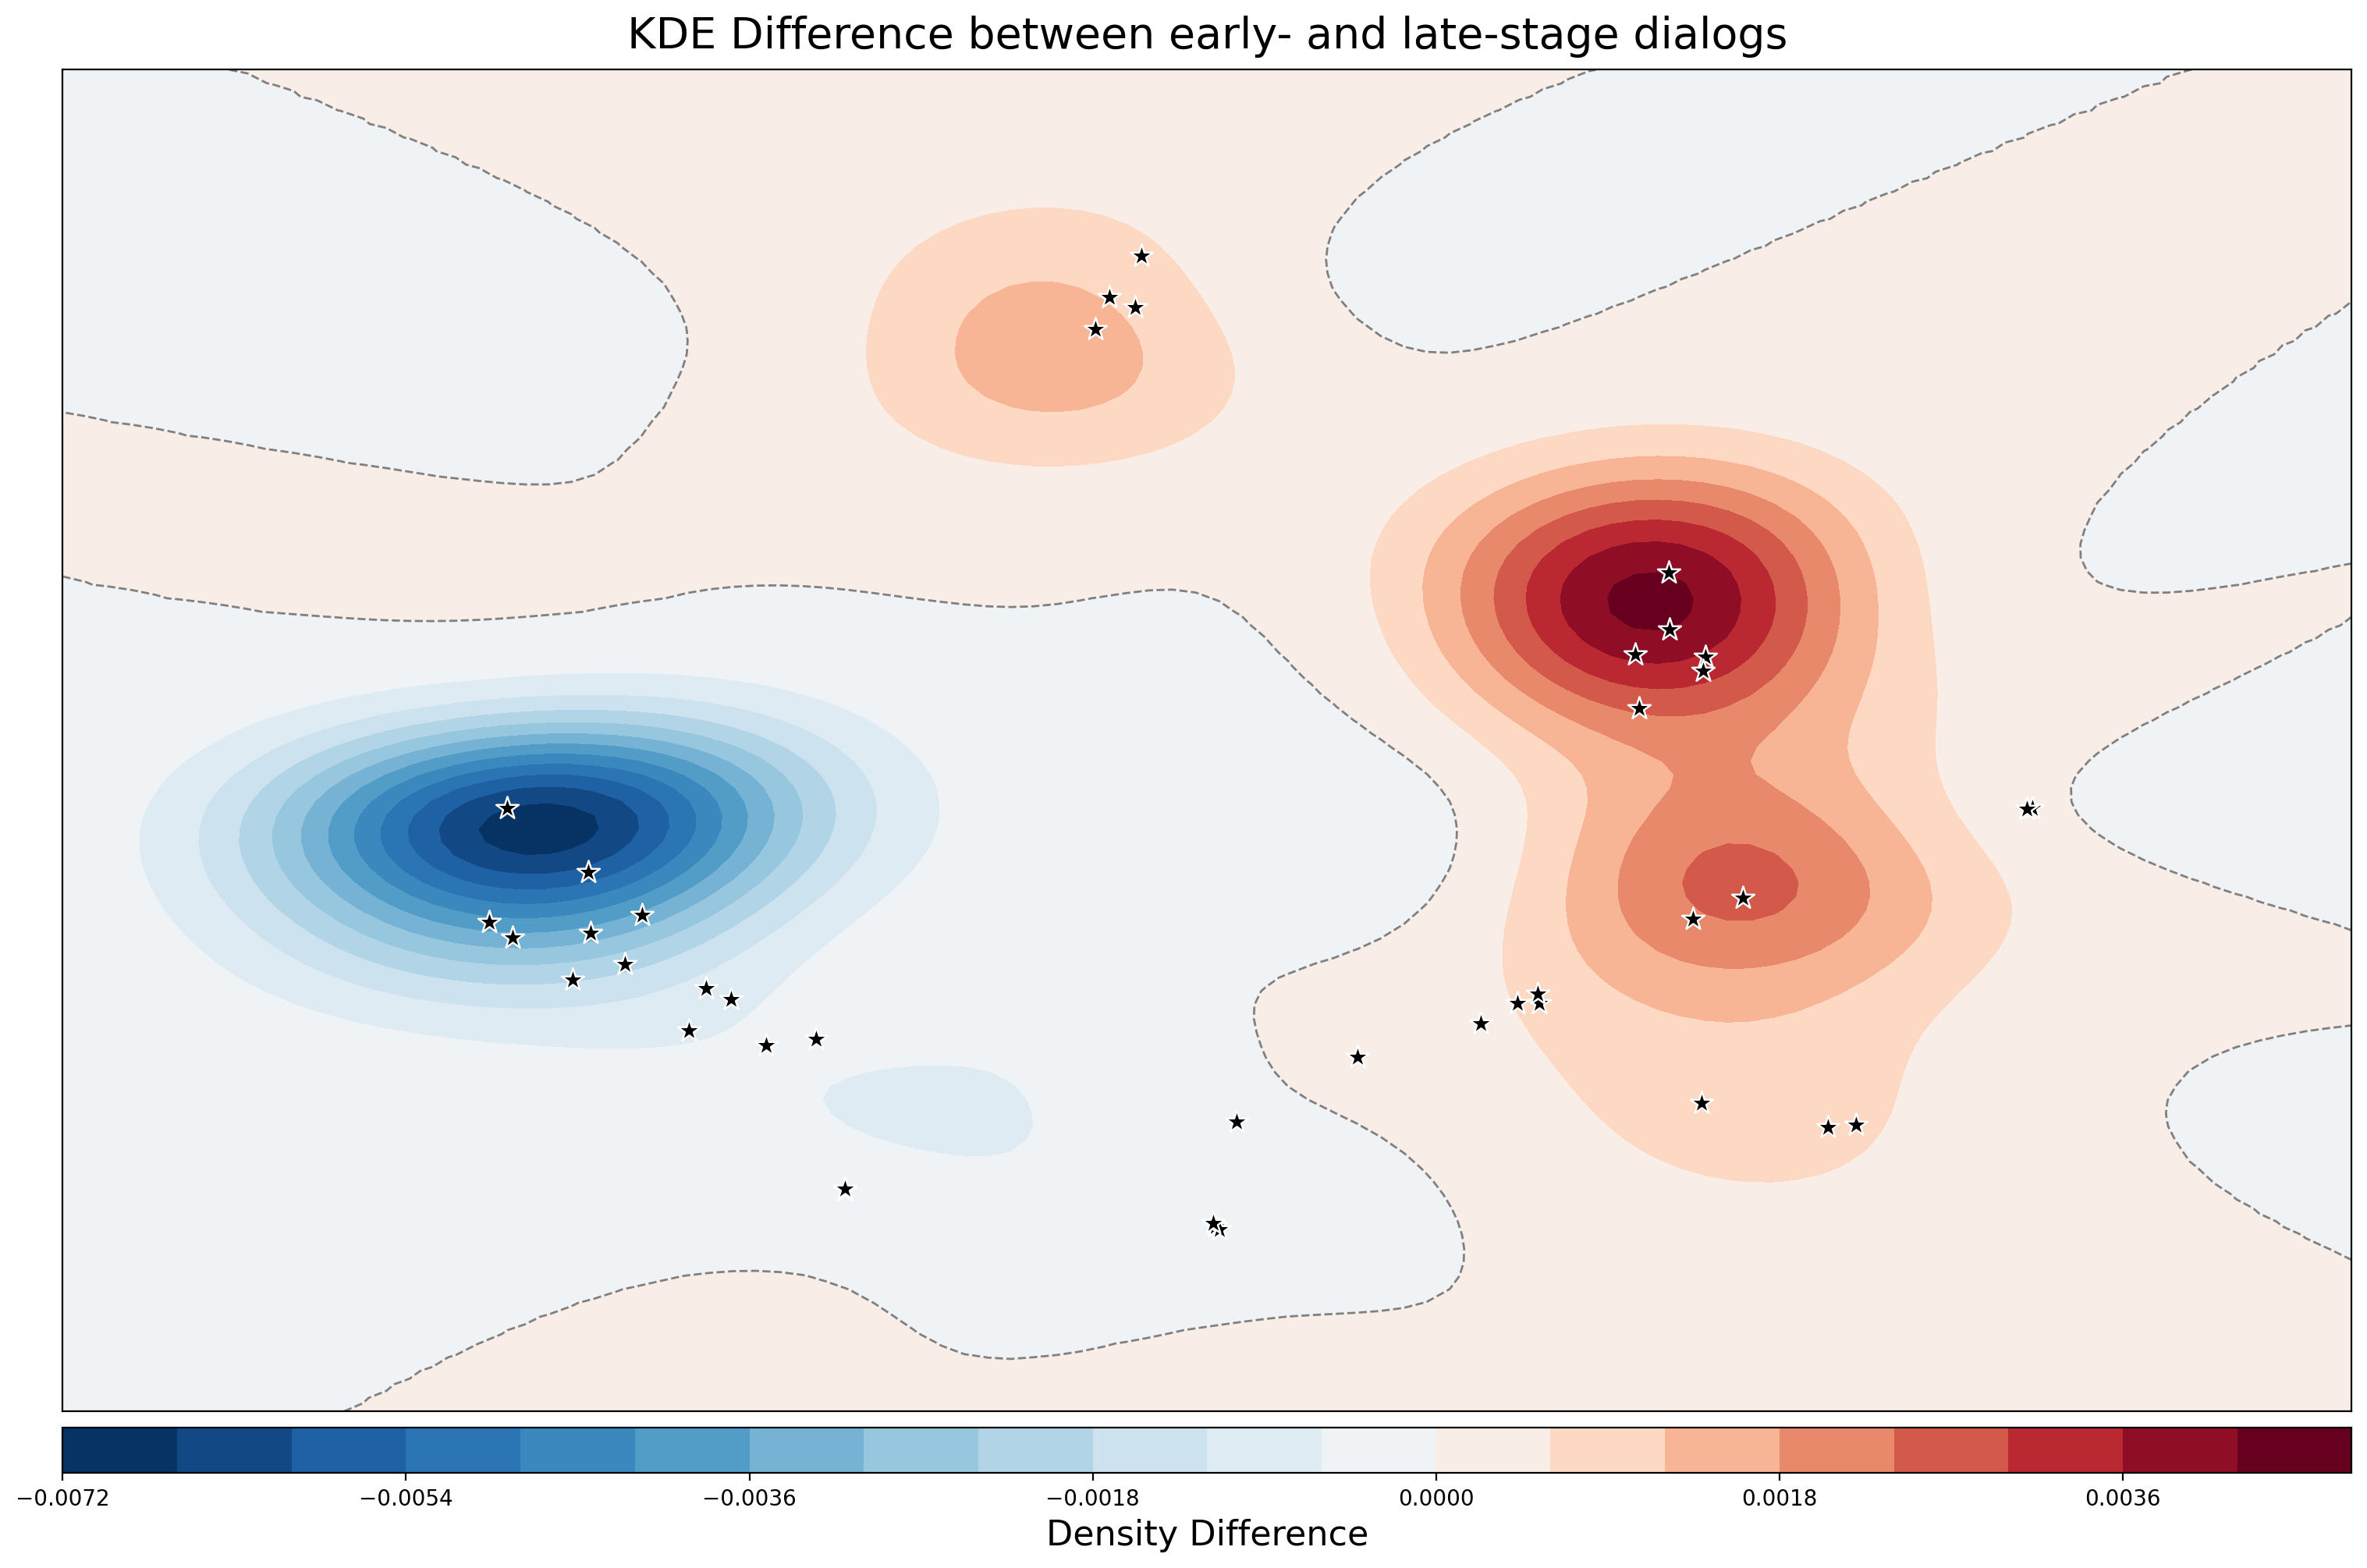

In [37]:
f1, f3 = plot_kde_difference(r_early, r_later, levels=15)
plt.show()

#### Figure 7: Collective communal trends over time using Lexical Richness

In [38]:
# Group the inputs over time as either by natural months/several days, or by every N instance
# Use month as default if further_division is False; support '10days' and 'everyNinst' as alternative
# Additionally, two modes are supported:
# (1) Rolling: using a rolling window instead of fully moving to the next N instance;
# (2) Cumulative: Instead of the average of current bin, consider cumulative average from the very start.
# In practice, we use _every_inst_num=200 and _rolling_inst_num=500

def group_inputs_over_time(dataset, further_division=None, _every_inst_num=100, _rolling_inst_num=500, rolling=False, cumulative=False):
    _by_group_col = {}
    current_batch_key, current_batch_count = None, 0
    dataset = sorted(dataset, key=lambda item: item['conversation_metadata']['timestamp'])
    
    for inst in dataset:
        if inst['processed_first_turn'] is not None and inst['processed_first_turn']['query_type'] == 'performing tasks':
            if further_division is None: # default to use month
                ym = datetime.fromisoformat(inst['conversation_metadata']['timestamp']).strftime('%Y-%m')
            elif further_division == '10days':
                ym = datetime.fromisoformat(inst['conversation_metadata']['timestamp']).strftime('%Y-%m-%d')
                ym = ym[:-1]
                if ym[-1] == '3': # count 30,31 into 20s
                    ym = ym[:-1] + '2'
                ym = ym + '1'
            elif further_division == 'everyNinst': # Collect every N instances as a bin, instead of hard timestamp division
                if current_batch_key is None or current_batch_count >= _every_inst_num: # start a new batch with current key
                    ym = datetime.fromisoformat(inst['conversation_metadata']['timestamp']).strftime('%Y-%m-%d %H:%M')
                    try:
                        assert current_batch_key is None or ym >= current_batch_key
                    except:
                        print(ym)
                        print(current_batch_key)
                        assert False
                    current_batch_key = ym
                    current_batch_count = 1
                else:
                    ym = current_batch_key
                    current_batch_count += 1
                    
            if ym not in _by_group_col:
                _by_group_col[ym] = []
            _by_group_col[ym].append(inst)
            
    prev_k = None
    sorted_ms = sorted(_by_group_col.keys())
    for _i, k in enumerate(sorted_ms):
        if cumulative is True and rolling is True:
            print('Cannot use "cumulative" and "rolling" together at this point.')
            assert False
        
        if rolling is True:
            if _i + int(_rolling_inst_num/_every_inst_num) > len(sorted_ms):
                _by_group_col = {item: _by_group_col[item] for item in sorted_ms[:_i]}
                return _by_group_col
                
            for _j in range(1, int(_rolling_inst_num/_every_inst_num)):
                if _i + _j < len(sorted_ms):
                    _by_group_col[k] += _by_group_col[sorted_ms[_i+_j]]
                else:
                    break
        
        if cumulative is True and prev_k is not None:
            _by_group_col[k] += _by_group_col[prev_k]
            
        prev_k = k
        
    return _by_group_col

In [39]:
# Collect data by model version
model_versions = {}
for u in ds:
    for item in ds[u]:
        _v = item['conversation_metadata']['model']
        if _v not in model_versions:
            model_versions[_v] = []
        model_versions[_v].append(item)

In [40]:
# Run the grouping over time and collect data by model version 

_mc_by_v = {}
for v in model_versions:
    _mc_by_v[v] = group_inputs_over_time(model_versions[v], further_division='everyNinst', _every_inst_num=200, cumulative=False) # long-term users

ds_communal = {}
for v in _mc_by_v:
    print(v)
    res = get_lex_richness(_mc_by_v[v], metric='mtld', mtld_thres=0.5, print_user=False)
    ds_communal[v] = res
print(sum([len(ds_communal[v]) for v in ds_communal])) # total data points (groups)

gpt-3.5-turbo-0301
gpt-4-0314
gpt-3.5-turbo-0613


gpt-3.5-turbo-0125
gpt-4-1106-preview
gpt-4-0125-preview
299


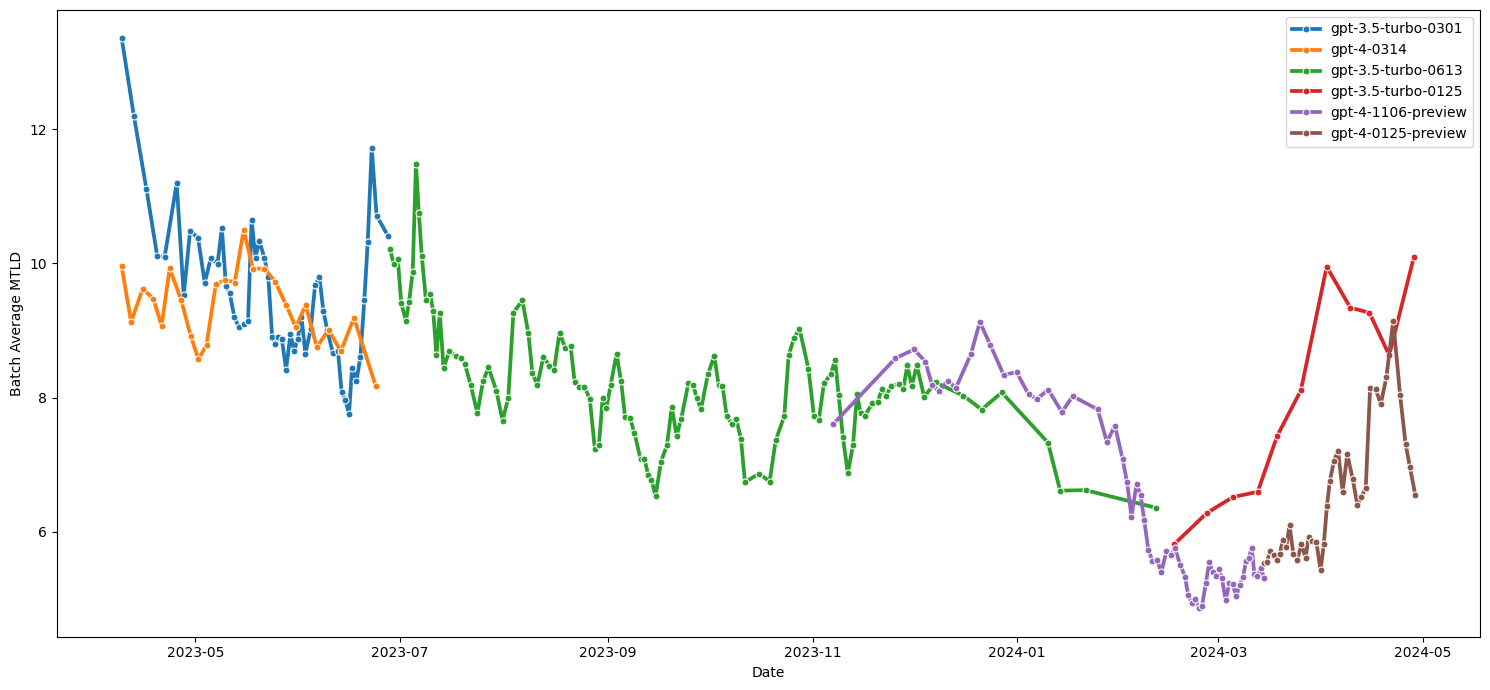

In [41]:
plt.figure(figsize=(15,7))
for v in ds_communal:
    df = pd.DataFrame(ds_communal[v].items(), columns=['Date', 'mtld'])
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %H:%M')
    df['ExpAvg'] = df['mtld'].ewm(span=5, adjust=False, min_periods=1).mean() # EMA smoothing
    sns.lineplot(data=df, x='Date', y='ExpAvg', label=v, marker='o', markersize=5, linewidth=2.7)

plt.ylabel('Batch Average MTLD')
plt.tight_layout()
plt.show()